# LLM Response Preference Classification

## Setup: imports, configuration, and experiment tracking

In [1]:
!pip install -q mlflow
!pip install -q ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 kB 9.6 MB/s eta 0:00:00


In [2]:
import ast
import copy
import gc
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
import random
import warnings

import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from functools import partial
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, PreTrainedTokenizerBase

SEED = 42
random.seed(SEED) # Used to permute responses.

torch.manual_seed(SEED) # Used to initialized weights and for dropout
torch.cuda.manual_seed_all(SEED) # Same as above but for GPU
torch.mps.manual_seed(SEED) # Same as above but for MPS
generator = torch.Generator().manual_seed(SEED)

# Environment
ENVIRONMENT = "KAGGLE" # "COLAB", "KAGGLE", "MAC"
if ENVIRONMENT == "KAGGLE":
    TARGET_DEVICE = "cuda"
    PROJECT_ROOT = "./"
elif ENVIRONMENT == "MAC":
    TARGET_DEVICE = "mps"
    PROJECT_ROOT = "./"
elif ENVIRONMENT == "COLAB":
    TARGET_DEVICE = "cuda"
    PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/LLM Classification Finetuning"
    from google.colab import drive
    drive.mount('/content/drive')


# Training
if ENVIRONMENT == "KAGGLE":
    BATCH_SIZE = 128
    NUM_WORKERS = 2
    MULTIPROCESSING_CONTEXT = None
elif ENVIRONMENT == "MAC":
    # To be used only when training the classifier with pre-encoded input.
    BATCH_SIZE = 512
    NUM_WORKERS = 6
    MULTIPROCESSING_CONTEXT = "fork"
elif ENVIRONMENT == "COLAB":
    BATCH_SIZE = 128
    NUM_WORKERS = 0
    MULTIPROCESSING_CONTEXT = None

In [3]:
# CLASSIFIER_WEIGHTS_FILE must be a full/absolute path. A relative path would
# resolve differently depending on where the process is run from.
if ENVIRONMENT == "KAGGLE":
    DATA_PATH = "/kaggle/input/competitions/llm-classification-finetuning" # Folder containing data
    CLASSIFIER_WEIGHTS_FILE = (
        "/kaggle/input/models/fernandoquintinojr/classifier-model-llm/pytorch/default/1/classifier_state_1_state_dict.pth"
    )
elif ENVIRONMENT == "MAC":
    DATA_PATH = "data" # Folder containing data
    CLASSIFIER_WEIGHTS_FILE = (
        "/Users/fernandoquintino/Documents/CS files/Kaggle/"
        "LLM Classification Finetuning/mlartifacts/"
        "819d636eea98462a89ecb508c1f0cddc/artifacts/"
        "best_model_classifier_state_dict/state_dict.pth"
    )
elif ENVIRONMENT == "COLAB":
    DATA_PATH = "data" # Folder containing data
    CLASSIFIER_WEIGHTS_FILE = os.path.join(
        PROJECT_ROOT,
        "classifier_state_1_state_dict.pth"
    )
    

print(f"ENVIRONMENT: {ENVIRONMENT}")
print("Data location:", os.path.join(PROJECT_ROOT,DATA_PATH))
print("DATA_PATH exists:", os.path.exists(os.path.join(PROJECT_ROOT,DATA_PATH)))
print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROJECT_ROOT exists:", os.path.exists(PROJECT_ROOT))
print("CLASSIFIER_WEIGHTS_FILE: ", CLASSIFIER_WEIGHTS_FILE)
print(
    "CLASSIFIER_WEIGHTS_FILE exists:",
    os.path.exists(CLASSIFIER_WEIGHTS_FILE)
    )

ENVIRONMENT: KAGGLE
Data location: /kaggle/input/competitions/llm-classification-finetuning
DATA_PATH exists: True
PROJECT_ROOT: ./
PROJECT_ROOT exists: True
CLASSIFIER_WEIGHTS_FILE:  /kaggle/input/models/fernandoquintinojr/classifier-model-llm/pytorch/default/1/classifier_state_1_state_dict.pth
CLASSIFIER_WEIGHTS_FILE exists: True


In [4]:
# SQLite backend (vs. MLflow's older file-store) - must be a genuine local
# path, not cloud-synced storage (e.g. Google Drive), which caused disk I/O
# errors due to SQLite's locking requirements.
mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT}/mlruns_v2")
EXPERIMENT_NAME = f"preference-classifier-{ENVIRONMENT}"
if mlflow.get_experiment_by_name(EXPERIMENT_NAME) is None:
    mlflow.create_experiment(EXPERIMENT_NAME,
                             artifact_location=f"{PROJECT_ROOT}/mlartifacts")
mlflow.set_experiment(EXPERIMENT_NAME)

2026/09/12 17:02:38 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/12 17:02:38 INFO mlflow.store.db.utils: Updating database tables


<Experiment: artifact_location='/kaggle/working/mlartifacts', creation_time=1789232560954, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789232560954, lifecycle_stage='active', name='preference-classifier-KAGGLE', tags={}, trace_location=None, workspace='default'>

## The Data

In [5]:
df = pd.read_csv(os.path.join(PROJECT_ROOT, DATA_PATH, "train.csv"))
# Convert one-hot winner columns to a single label via argmax:
# 0=response_a, 1=response_b, 2=tie.
labels_one_hot = df[["winner_model_a", "winner_model_b", "winner_tie"]]
labels = labels_one_hot.values.argmax(axis=1)

train_df, val_df, train_labels, val_labels = train_test_split(
    df,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)
val_df, test_df, val_labels, test_labels = train_test_split(
    val_df,
    val_labels,
    test_size=0.5,
    stratify=val_labels,
    random_state=SEED
)


In [6]:
def parse_conversation(cell: str) -> list[str]:
    """
    Parses a stringified list of conversation turns.

    Args:
        cell: A raw CSV cell expected to look like a Pythong list
        literal (e.g., '["turn1", "turn2"]).
    Returns:
        The parsed list of turns. If parse fails, it returns cell (the
        raw string).
    """
    try:
        return ast.literal_eval(cell)
    except (ValueError, SyntaxError, TypeError):
        return [cell]

def format_conversation(turns: list[str]) -> str:
    """
    Joins conversation turns into one string for tokenization.

    Args:
        turns: The turns oined with a blank line between each.
    Returns:
        The turns joined with a blank line between each. Any leftover
        JSON-style escaping slashes cleaned up (backslsashed-escaped
        slashes, unpaired surrgate characters).
    """
    text = "\n\n".join(turns).replace("\\/", "/")
    return text.encode("utf", errors="ignore").decode("utf-8")

def token_lengths(texts: list[str]) -> list[int]:
    encoded = tokenizer(texts, add_special_tokens=False)
    return [len(ids) for ids in encoded["input_ids"]]

def summarize(name, lengths):
    arr = np.array(lengths)
    print(
        f"{name}: mean={arr.mean():.1f}, median={np.median(arr):.0f}, "
        f"95th={np.percentile(arr, 95):.0f}, "
        f"99th={np.percentile(arr, 99):.0f}, max={arr.max()}"
    )

In [7]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-small")

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

In [8]:
print("Text before cleaning:")
idx = 9
print(train_df["prompt"][idx])

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=SyntaxWarning)
    for col in ["prompt",  "response_a", "response_b"]:
        train_df[col] = train_df[col].apply(parse_conversation).apply(format_conversation)
        val_df[col] = val_df[col].apply(parse_conversation).apply(format_conversation)
        test_df[col] = test_df[col].apply(parse_conversation).apply(format_conversation)
        df[col] = df[col].apply(parse_conversation).apply(format_conversation)

print("\nText after cleaning")
print(train_df["prompt"][idx])

Text before cleaning:
["From now, you *always* have to talk as if you are a cute girl who likes to use \"owo\" and similar slangs a lot. \/ Hello! Tell me who you are.","What's your favorite food?"]

Text after cleaning
From now, you *always* have to talk as if you are a cute girl who likes to use "owo" and similar slangs a lot. / Hello! Tell me who you are.

What's your favorite food?


## Model Architecture


**Input variables**
```
prompt = prompt
response_0 = either response_a or response_b
response_1 = the other response_a/b
input = [CLS] prompt [SEP] response_0 [SEP] response_1 [SEP]
```
**Models**
```
model_encoder = DeBERTA v3 small
model_classifier = DeepPreferenceClassifier 3 blocks
model = PreferenceModel (wraps the encoder and classifier)
```
**Pipeline**
```
input -> model -> logits
```
The PreferenceModel class wraps the encoder and classifier as follows:
```
input -> model_encoder -> encoded

encoded -> model_classifier -> logits
```



In [9]:
prompt_lens = token_lengths(train_df["prompt"].tolist())
response_a_lens = token_lengths(train_df["response_a"].tolist())
resposne_b_lens = token_lengths(train_df["response_b"].tolist())

summarize("prompt", prompt_lens)
summarize("response_a", response_a_lens)
summarize("response_b", resposne_b_lens)


prompt: mean=80.1, median=20, 95th=316, 99th=1046, max=6584
response_a: mean=289.4, median=227, 95th=798, 99th=1470, max=6377
response_b: mean=291.4, median=229, 95th=790, 99th=1518, max=15670


### Datasets

In [10]:
class CrossEncoderDataset(Dataset):
    """
    A custom Dataset for the cross-encoder. Encodes prompt, response_a,
    and response_b as one input (and swaps the responses with the given
    probability): [CLS] prompt [SEP] response_0 [SEP] response_1 [SEP]
    """
    def __init__(
            self,
            prompts: list[str],
            responses_a: list[str],
            responses_b: list[str],
            labels: np.ndarray,
            tokenizer: PreTrainedTokenizerBase,
            prompt_max_len: int = 30,
            response_max_len: int = 239,
            prob: float = 0.5,
    ) -> None:
        """
        Initializes the dataset.

        Args:
            prompts: A list of strings containing the prompts.
            responses_a: A list of strings containing responses to
                model_a.
            responses_b: A list of strings containing responses to
                model_b.
            labels: A 1-d array of integers containing the preferred
                response:
                    - 0: response_a preferred
                    - 1: response_b preferred
                    - 2: tie
            tokenizer: A tokenizer used to convert text into token ids.
            prompt_max_len: Max tokens reserved for the prompt segment.
            response_max_len: Max tokens reserved for each response
                segment.
            prob: The probability (between 0 and 1) of permuting the
                order of responses.
        """
        self.prompts = prompts
        self.responses_a = responses_a
        self.responses_b = responses_b
        self.labels = labels
        self.tokenizer = tokenizer
        self.prompt_max_len = prompt_max_len
        self.response_max_len = response_max_len
        self.prob = prob

    def __len__(self) -> int:
        """
        Returns the number of samples in the dataset.
        """
        return len(self.prompts)

    def __getitem__(self, idx: int) -> dict:
        """
        Builds one cross-encoder sequence: [CLS] prompt [SEP] response_0
        [SEP] response_1 [SEP].

        Args:
            idx: The index of the sample to retrieve.

        Returns:
            dict: A dictionary containing:
                - input_ids (Tensor): Token ids for the full sequence.
                - attention_mask (Tensor): All 1s - no padding yet.
                - label (Tensor): Integer class label 0/1/2, adjusted if
                    swapped.
                - idx (int): The original index.
        """
        prompt = self.prompts[idx]
        label = self.labels[idx]
        response_a = self.responses_a[idx]
        response_b = self.responses_b[idx]

        if random.random() < self.prob:
            response_a, response_b = response_b, response_a
            if label == 1:
                label = 0
            elif label == 0:
                label = 1
        response_0, response_1 = response_a, response_b

        prompt_ids = self.tokenizer(
            prompt,
            add_special_tokens=False,
            truncation=True,
            max_length=self.prompt_max_len,
        )["input_ids"]
        response_0_ids = self.tokenizer(
            response_0,
            add_special_tokens=False,
            truncation=True,
            max_length=self.response_max_len,
        )["input_ids"]
        response_1_ids = self.tokenizer(
            response_1,
            add_special_tokens=False,
            truncation=True,
            max_length=self.response_max_len
        )["input_ids"]

        input_ids = (
            [self.tokenizer.cls_token_id]
            + prompt_ids
            + [self.tokenizer.sep_token_id]
            + response_0_ids
            + [self.tokenizer.sep_token_id]
            + response_1_ids
            + [self.tokenizer.sep_token_id]
        )

        attention_mask = [1] * len(input_ids)
        label = torch.tensor(label, dtype=torch.long)

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "label": label,
            "idx": idx,
        }




In [11]:
def collate_cross_encoder(
        batch: list[dict],
        tokenizer: PreTrainedTokenizerBase,
) -> dict:
    """
    Pads a batch of CrossEncoderDataset samples to the batch's own
    longest sequence, instead of a fixed length.

    Args:
        batch: A list of of samples, each from CrossEncoderDataset.
        tokenizer: The tokenizer used to pad input_ids/attention_mask.

    Returns:
        dict: A dictionary containing:
            - input_ids (Tensor): Padded token ids, shape
                (batch_size, max_len).
            - attention_mask (Tensor): Padded attention mask, shape
                (batch_size, max_len).
            - label (Tensor): Class labels, shape (batch_size,).
            - idx (Tensor): Orginal dataset indices, shape
                (batch_size,).
    """
    labels = torch.stack([sample["label"] for sample in batch])
    idx = torch.tensor(
        [sample["idx"] for sample in batch], dtype=torch.long
    )

    to_pad = [
        {
            "input_ids": sample["input_ids"],
            "attention_mask": sample["attention_mask"]
        }
        for sample in batch
    ]

    padded = tokenizer.pad(to_pad, padding=True, return_tensors="pt")

    return {
        "input_ids": padded["input_ids"],
        "attention_mask": padded["attention_mask"],
        "label": labels,
        "idx": idx,
    }

In [12]:
class EncodedPreferenceDataset(Dataset):
    """
    A custom Dataset class for classifier-only training. The class handling
    encoded prompts/response_0/response_1, and preference labels.
    """
    def __init__(self, encoded, labels, indices,):
        """
        Initializes the dataset.

        Args:
            encoded (Tensor): A tensor containing the encoded
                [CLS] prompt [SEP] response_0 [SEP] response_1.
            labels (Tensor): A tensor of integers containing the preferred
                response.
                - 0: response_a preferred
                - 1: response_b preferred
                - 2: tie
            indices (ndarray): Array of integer row positions into the full
                precomputed tensors, e.g. train_df.index.values.
        """
        self.indices = indices
        self.encoded= encoded
        self.labels = labels

    def __len__(self):
        """
        Returns the number of samples in the dataset.

        Returns:
            int: The number of samples in the dataset.
        """
        return len(self.indices)

    def __getitem__(self, idx):
        """
        Retrieves one sample.

        Args:
            idx (int): Index of the sample to retrieve.

        Returns:
            dict: A dictionary containing:
                - encoded (Tensor): A tensor containing encoded
                prompt/response_0/response_1.
                - label (Tensor): Integer class label 0/1/2.
        """
        row = self.indices[idx]
        encoded = self.encoded[row]

        label = self.labels[row]



        return {
            "encoded": encoded,
            "idx": idx,
            "label": label,
            }

### Models

In [13]:
class DeepPreferenceClassifier(nn.Module):
    """
    Classification head that takes pooled encoder representation and
    predicts which response is preferred:
        - 0 response_0 preferred
        - 1 response_1 preferred
        - 2 tie
    """

    def __init__(
            self,
            input_dim: int,
            hidden_state: int = 768,
            num_classes: int = 3,
            num_blocks: int = 2,
            dropout: float = 0.1,
    ) -> None:
        """
        Initializes the classifier.

        Args:
            input_dim: The dimension of the pooled input vetor.
            hidden_state: The hidden dimension for the residual block.
            num_classes: The number of classes.
            num_blocks: The number of residual blocks.
            droptout: Dropout probability used throughout the head.
        """
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_state)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_state, hidden_state),
                nn.LayerNorm(hidden_state),
                nn.ReLU(),
                nn.Dropout(dropout)
            )
            for _ in range(num_blocks)
        ])

        self.fc2 = nn.Linear(hidden_state, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Executes the forward pass to generate classification logits.

        Args:
            x: A pooled representation, shape (batch_size, input_dim).

        Returns:
            Tensor: Classification logits.
        """
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        for block in self.blocks:
            x = x + block(x)

        logits = self.fc2(x)

        return logits

In [14]:
class PreferenceModel(nn.Module):
    """
    A model that takes the encoder model and the classifier
    model to create the full end-to-end model. The model first encodes
    prompt/response_0/response_1 through the encoder model in one
    pass. The output is fed through the classifier model to predict the
    user preference:
        - 0: response_0 is preferred
        - 1: response_1 is preferred
        - 2: tie
    """

    def __init__(
            self,
            model_encoder: nn.Module,
            model_classifier: DeepPreferenceClassifier,
    ) -> None:
        """
        Initializes the model with the model encoder and model classifier.

        Args:
            model_encoder (nn.Module): A pretrained encoder model
                (e.g. DebertaV2Model) that outputs last_hidden_state given
                input_ids and attention_mask.
            model_classifier (PreferenceClassifier): The classification head
                that takes encoder outputs and predicts preference.
        """
        super().__init__()
        self.model_encoder = model_encoder
        self.model_classifier = model_classifier

    def forward(
            self,
            input_ids: torch.Tensor,
            attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        """
        Executes the forward pass of the model.

        Args:
            input_ids: The input_ids.
            Attention_mask: The attention mask for the input_ids.

        Returns:
            Tensor: Classifier logits.
        """
        output = self.model_encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:,0,:]
        logits = self.model_classifier(output)

        return logits

## Training

In [15]:
def train_epoch(
        model: PreferenceModel,
        loader: DataLoader,
        device: torch.device,
        optimizer: torch.optim.Optimizer,
        loss: nn.Module,
        scaler: torch.amp.GradScaler
) -> tuple[float, float]:
    """
    Trains the model for one epoch.

    Args:
        model: The model that takes prompt/response_0/response_1 and its
            mask and outputs the logits.
        loader: The data loader for CrossEncoderDataset.
        device: The device to process the calculations (e.g., "cuda").
        optimizer: The optimizer.
        loss: The loss function.
        scaler: Scales the loss to prevent fp16 underflow.

    Returns:
        epoch_loss: The average loss for the epoch.
        epoch_acc: The average accuracy for the epoch.
    """
    running_loss = 0.0
    correct = 0
    total = 0

    model.train()
    for batch in tqdm(loader, leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        with torch.autocast(device_type=device.type, dtype=torch.float16):
            output = model(
                batch["input_ids"],
                batch["attention_mask"],
            )
            batch_loss = loss(output, batch["label"])
        scaler.scale(batch_loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Since last batch may be a different size, we multiply each
        # batch loss by the batch size to get a sum, so the final
        # division by total averages correctly.
        running_loss += batch_loss.item() * batch["label"].size(0)
        predicted = torch.argmax(output, 1)
        total += batch["label"].size(0)
        correct += (predicted == batch["label"]).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100

    return epoch_loss, epoch_acc

def validate_epoch(
        model: PreferenceModel,
        loader: DataLoader,
        device: torch.device,
        loss: nn.Module,
    ) -> tuple[float, float]:
    """
    Validates the model for one epoch.

    Args:
        model: The model that takes prompt/response_0/response_1 and its
            mask and outputs the logits.
        loader: The data loader for CrossEncoderDataset.
        device: The device to process the calculations (e.g., "cuda").
        loss: The loss function.

    Returns:
        epoch_loss: The average loss for the epoch.
        epoch_acc: The average accuracy for the epoch.
    """
    running_loss = 0.0
    correct = 0
    total = 0

    model.eval()
    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            batch = {k: v.to(device) for k, v in batch.items()}

            with torch.autocast(device_type=device.type, dtype=torch.float16):
                output = model(
                    batch["input_ids"],
                    batch["attention_mask"],
                )
                batch_loss = loss(output, batch["label"])

            # Since last batch may be a different size, we multiply each
            # batch loss by the batch size to get a sum, so the final
            # division by total averages correctly.
            running_loss += batch_loss.item() * batch["label"].size(0)
            predicted = torch.argmax(output, 1)
            total += batch["label"].size(0)
            correct += (predicted == batch["label"]).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100

    return epoch_loss, epoch_acc

def train_model(
        model: PreferenceModel,
        train_loader: DataLoader,
        val_loader: DataLoader,
        device: torch.device,
        optimizer: torch.optim.Optimizer,
        loss: nn.Module,
        num_epochs: int,
        scaler: torch.amp.GradScaler,
        run_name: str | None = None,
        scheduler: torch.optim.lr_scheduler.ReduceLROnPlateau | None = None,
        ) -> dict:
    """
    Trains the model for the specified epochs. mlflow is used to track
    the runs.

    Args:
        model: The model that takes prompt/response_0/response_1 and its
            mask and outputs the logits.
        train_loader: The train loader for CrossEncoderDataset.
        val_loader: The val loader for CrossEncoderDataset.
        device: The device to process the calculations (e.g., "cuda").
        optimizer: The optimizer.
        loss: The loss function.
        num_epochs: The number of epochs to train the model.
        scaler: Scales the loss to prevent fp16 underflow.
        run_name: The name of the run. Defaults to None.
        scheduler: Updates the learning rate based upon val loss.
            Defaults to None.

    Returns:
        dict: A dictionary containing:
            - loss_train_history (list[float]): The history of the
                training loss per epoch.
            - acc_train_history (list[float]): The history of the
                training accuracy per epoch.
            - loss_val_history (list[float]): The history of the val
                loss per epoch.
            - acc_val_history (list[float]): The history of the val
                accuracy per epoch.
            - best_model (PreferenceModel): Model with best loss on the
                validation set.
            - best_loss (float): The best loss on the validation set.
            - best_model_acc (float): The accuracy of the best_model.
    """
    loss_train_history = []
    acc_train_history = []
    loss_val_history = []
    acc_val_history = []
    best_loss = float("inf")
    best_model_acc = 0.0
    best_model = copy.deepcopy(model)

    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("learning_rate", optimizer.param_groups[0]["lr"])
        mlflow.log_param("batch_size", train_loader.batch_size)
        mlflow.log_param("num_epochs", num_epochs)
        mlflow.log_param("optimizer_type", type(optimizer).__name__)
        if scheduler is not None:
            mlflow.log_param("scheduler_type", type(scheduler).__name__)
            mlflow.log_params(scheduler.state_dict())
        mlflow.log_param("model_type", type(model).__name__)

        print(f"Training on device {device} for {num_epochs} epochs:")
        model = model.to(device)
        if torch.cuda.device_count() > 1:
            model = nn.DataParallel(model)

        epoch_bar = tqdm(range(num_epochs), desc="Epochs")
        for epoch in epoch_bar:
            epoch_train_loss, epoch_train_acc = train_epoch(
                model,
                train_loader,
                device,
                optimizer,
                loss,
                scaler
            )
            loss_train_history.append(epoch_train_loss)
            acc_train_history.append(epoch_train_acc)

            epoch_val_loss, epoch_val_acc = validate_epoch(
                model,
                val_loader,
                device,
                loss
            )
            loss_val_history.append(epoch_val_loss)
            acc_val_history.append(epoch_val_acc)

            mlflow.log_metric("train_loss", epoch_train_loss, step=epoch)
            mlflow.log_metric("train_acc", epoch_train_acc, step=epoch)
            mlflow.log_metric("val_loss", epoch_val_loss, step=epoch)
            mlflow.log_metric("val_acc", epoch_val_acc, step=epoch)
            mlflow.log_metric(
                "learning_rate",
                optimizer.param_groups[0]["lr"],
                step=epoch
            )

            if scheduler is not None:
                scheduler.step(epoch_val_loss)

            if epoch_val_loss < best_loss:
                if isinstance(model, nn.DataParallel):
                    best_model = copy.deepcopy(model.module)
                else:
                    best_model = copy.deepcopy(model)
                best_model_acc = epoch_val_acc
                best_loss = epoch_val_loss
                mlflow.pytorch.log_state_dict(
                    best_model.state_dict(),
                    artifact_path="best_model_state_dict"
                )

            epoch_bar.set_description(
                f"Epoch {epoch + 1} | Train loss: {epoch_train_loss:.4f} acc: "
                f"{epoch_train_acc:.2f}% | Val loss: {epoch_val_loss:.4f} acc:"
                f" {epoch_val_acc:.2f}%"
            )

        mlflow.log_metric("best_model_val_acc", best_model_acc)
        mlflow.log_metric("best_val_loss", best_loss)


    print(
        f"Training Complete. Best Val loss: {best_loss} (Val Acc "
        f"{best_model_acc})"
    )

    return {
        "loss_train_history": loss_train_history,
        "acc_train_history": acc_train_history,
        "loss_val_history": loss_val_history,
        "acc_val_history": acc_val_history,
        "best_model_acc": best_model_acc,
        "best_model": best_model,
        "best_loss": best_loss,
    }

In [16]:
model_encoder = AutoModel.from_pretrained("microsoft/deberta-v3-small", torch_dtype=torch.float32)
model_encoder.gradient_checkpointing_enable()
model_classifier = DeepPreferenceClassifier(input_dim=768, num_blocks=3)
model = PreferenceModel(model_encoder,model_classifier)

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [17]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device}")

Using cuda


In [18]:
run_validation = False
loss = nn.CrossEntropyLoss()

val_dataset = CrossEncoderDataset(
    prompts=val_df["prompt"].tolist(),
    responses_a=val_df["response_a"].tolist(),
    responses_b=val_df["response_b"].tolist(),
    labels=val_labels,
    tokenizer=tokenizer,
    prob=0,
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    multiprocessing_context=MULTIPROCESSING_CONTEXT,
    collate_fn=partial(collate_cross_encoder, tokenizer=tokenizer),
    generator=generator,
)


# Validation before training
gc.collect()
if device.type == "cuda":
    torch.cuda.empty_cache()
elif device.type == "mps":
    torch.mps.empty_cache()
if device.type == TARGET_DEVICE:
    model = model.to(device)
    if run_validation:
        print(validate_epoch(model, val_loader, device, loss))
else:
    print(
        f"Device is set to {device}. Needs to be set to {TARGET_DEVICE}."
    )

### Stage 0: Build the embedding cache

In [19]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-small")

full_dataset = CrossEncoderDataset(
    prompts=df["prompt"].tolist(),
    responses_a=df["response_a"].tolist(),
    responses_b=df["response_b"].tolist(),
    labels=labels,
    tokenizer=tokenizer,
    prob=0
)

full_loader = DataLoader(
    full_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=partial(collate_cross_encoder, tokenizer=tokenizer),
    num_workers=6,
    multiprocessing_context=MULTIPROCESSING_CONTEXT,
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [20]:
# Preproccess input through encoder:
#device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
run_encoding = False # Warning: Will replace existing file
encoded_filename = os.path.join(PROJECT_ROOT, "cross-encoded_data.pt")
print(f"Encoded file: {encoded_filename}")
print(f"File exists: {os.path.exists(encoded_filename)}")
if run_encoding:
    model_encoder = AutoModel.from_pretrained("microsoft/deberta-v3-small", torch_dtype=torch.float32)
    model_encoder.gradient_checkpointing_enable()

    model_encoder = model_encoder.to(device)
    print(f"Encoding using device: {device}")
    model_encoder.eval()

    hidden_size = model_encoder.config.hidden_size
    num_samples = len(full_dataset)

    encoded = torch.zeros(num_samples, hidden_size)
    dataset_idx =torch.zeros(num_samples, dtype=torch.long)

    with torch.no_grad():
        for batch in tqdm(full_loader):
            idx = batch["idx"]
            batch = {k: v.to(device) for k,v in batch.items() if k != "idx"}
            with torch.autocast(device_type=device.type, dtype=torch.float16):
                output = model_encoder(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).last_hidden_state[:,0,:]
            encoded[idx] = output.float().cpu()
            dataset_idx[idx] =idx.cpu()

    print("Saving...")
    torch.save(
        {"encoded": encoded, "label": torch.tensor(labels), "idx": dataset_idx},
        encoded_filename
    )

    print("Saved file")

Encoded file: ./cross-encoded_data.pt
File exists: False


In [21]:
def plot_results(results):
    epochs = range(1, len(results["loss_train_history"]) + 1)

    # Loss history
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(epochs, results["loss_train_history"], marker="o", color="blue", label="Train")
    ax.plot(epochs, results["loss_val_history"], marker="o", color="red", label="Val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Loss per Epoch")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()

    # Accuracy History
    fig, ax = plt.subplots(figsize=(7,4.5))
    ax.plot(epochs, results["acc_train_history"], marker="o", color="blue", label="Train")
    ax.plot(epochs, results["acc_val_history"], marker="o", color="red", label="Val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accracy per Epoch")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()

#epochs = range(1, len(results["loss_train_history"]) + 1)

### Stage 1: Pretrain the classifier head

In [22]:
def train_classifier_epoch(
    model: DeepPreferenceClassifier,
    loader: DataLoader,
    device: torch.device,
    optimizer: torch.optim.Optimizer,
    loss: nn.Module,
    scaler: torch.amp.GradScaler
) -> tuple[float, float]:
    """
    Trains the model for one epoch.

    Args:
        model: The classifier that takes encoded input and outputs the logits.
        loader: The data loader for EncodedPreferenceDataset.
        device: The device to process the calculations (e.g., "cuda").
        optimizer: The optimizer.
        loss: The loss function.
        scaler: Scales the loss to prevent fp16 underflow.

    Returns:
        epoch_loss: The average loss for the epoch.
        epoch_acc: The average accuracy for the epoch.
    """
    running_loss = 0.0
    correct = 0
    total = 0

    model.train()
    for batch in tqdm(loader, leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        with torch.autocast(device_type=device.type, dtype=torch.float16):
            output = model(
                batch["encoded"],
            )
            batch_loss = loss(output, batch["label"])
        scaler.scale(batch_loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Since last batch may be a different size, we multiply each
        # batch loss by the batch size to get a sum, so the final
        # division by total averages correctly.
        running_loss += batch_loss.item() * batch["label"].size(0)
        predicted = torch.argmax(output, 1)
        total += batch["label"].size(0)
        correct += (predicted == batch["label"]).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100

    return epoch_loss, epoch_acc

def validate_classifier_epoch(
    model: DeepPreferenceClassifier,
    loader: DataLoader,
    device: torch.device,
    loss: nn.Module,
) -> tuple[float, float]:
    """
    Validates the model for one epoch.

    Args:
        model: The classifier that takes encoded input and outputs the logits.
        loader: The data loader for EncodedPreferenceDataset.
        device: The device to process the calculations (e.g., "cuda").
        loss: The loss function.

    Returns:
        epoch_loss: The average loss for the epoch.
        epoch_acc: The average accuracy for the epoch.
    """
    running_loss = 0.0
    correct = 0
    total = 0

    model.eval()
    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            batch = {k: v.to(device) for k, v in batch.items()}

            with torch.autocast(device_type=device.type, dtype=torch.float16):
                output = model(
                    batch["encoded"],
                )
                batch_loss = loss(output, batch["label"])

            # Since last batch may be a different size, we multiply each
            # batch loss by the batch size to get a sum, so the final
            # division by total averages correctly.
            running_loss += batch_loss.item() * batch["label"].size(0)
            predicted = torch.argmax(output, 1)
            total += batch["label"].size(0)
            correct += (predicted == batch["label"]).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100

    return epoch_loss, epoch_acc

def train_classifier_model(
    model: DeepPreferenceClassifier,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    optimizer: torch.optim.Optimizer,
    loss: nn.Module,
    num_epochs: int,
    scaler: torch.amp.GradScaler,
    run_name: str | None = None,
    scheduler: torch.optim.lr_scheduler.ReduceLROnPlateau | None = None,
    ) -> dict:
    """
    Trains the model for the specified epochs. mlflow is used to track
    the runs.

    Args:
        model: The classifier that takes encoded input
            and outputs the logits.
        train_loader: The train loader for EncodedPreferenceDataset.
        val_loader: The val loader for EncodedPreferenceDataset.
        device: The device to process the calculations (e.g., "cuda").
        optimizer: The optimizer.
        loss: The loss function.
        num_epochs: The number of epochs to train the model.
        scaler: Scales the loss to prevent fp16 underflow.
        run_name: The name of the run. Defaults to None.
        scheduler: Updates the learning rate based upon val loss.
            Defaults to None.

    Returns:
        dict: A dictionary containing:
            - loss_train_history (list[float]): The history of the
                training loss per epoch.
            - acc_train_history (list[float]): The history of the
                training accuracy per epoch.
            - loss_val_history (list[float]): The history of the val
                loss per epoch.
            - acc_val_history (list[float]): The history of the val
                accuracy per epoch.
            - best_model (DeepPreferenceClassifier): Model with best loss on the
                validation set.
            - best_loss (float): The best loss on the validation set.
            - best_model_acc (float): The accuracy of the best_model.
    """
    loss_train_history = []
    acc_train_history = []
    loss_val_history = []
    acc_val_history = []
    best_loss = float("inf")
    best_model_acc = 0.0
    best_model = copy.deepcopy(model)
    best_epoch = 0

    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("learning_rate", optimizer.param_groups[0]["lr"])
        mlflow.log_param("batch_size", train_loader.batch_size)
        mlflow.log_param("num_epochs", num_epochs)
        mlflow.log_param("optimizer_type", type(optimizer).__name__)
        if scheduler is not None:
            mlflow.log_param("scheduler_type", type(scheduler).__name__)
            mlflow.log_params(scheduler.state_dict())
        mlflow.log_param("model_type", type(model).__name__)

        print(f"Training on device {device} for {num_epochs} epochs:")
        model = model.to(device)
        if torch.cuda.device_count() > 1:
            model = nn.DataParallel(model)

        epoch_bar = tqdm(range(num_epochs), desc="Epochs")
        for epoch in epoch_bar:
            epoch_train_loss, epoch_train_acc = train_classifier_epoch(
                model,
                train_loader,
                device,
                optimizer,
                loss,
                scaler
            )
            loss_train_history.append(epoch_train_loss)
            acc_train_history.append(epoch_train_acc)

            epoch_val_loss, epoch_val_acc = validate_classifier_epoch(
                model,
                val_loader,
                device,
                loss
            )
            loss_val_history.append(epoch_val_loss)
            acc_val_history.append(epoch_val_acc)

            mlflow.log_metric("train_loss", epoch_train_loss, step=epoch)
            mlflow.log_metric("train_acc", epoch_train_acc, step=epoch)
            mlflow.log_metric("val_loss", epoch_val_loss, step=epoch)
            mlflow.log_metric("val_acc", epoch_val_acc, step=epoch)
            mlflow.log_metric(
                "learning_rate",
                optimizer.param_groups[0]["lr"],
                step=epoch
            )

            if scheduler is not None:
                scheduler.step(epoch_val_loss)

            if epoch_val_loss < best_loss:
                if isinstance(model, nn.DataParallel):
                    best_model = copy.deepcopy(model.module)
                else:
                    best_model = copy.deepcopy(model)
                best_model_acc = epoch_val_acc
                best_loss = epoch_val_loss
                mlflow.pytorch.log_state_dict(
                    best_model.state_dict(),
                    artifact_path="best_model_classifier_state_dict"
                )
                best_epoch = epoch + 1

            epoch_bar.set_description(
                f"Epoch {epoch + 1} | Train loss: {epoch_train_loss:.4f} acc: "
                f"{epoch_train_acc:.2f}% | Val loss: {epoch_val_loss:.4f} acc:"
                f" {epoch_val_acc:.2f}%"
            )

        mlflow.log_metric("best_model_val_acc", best_model_acc)
        mlflow.log_metric("best_val_loss", best_loss)


    print("Training Complete.")
    print(f"Best Val loss: {best_loss}")
    print(f"Val Acc: {best_model_acc}")
    print(f"Best epoch: {best_epoch}")

    return {
        "loss_train_history": loss_train_history,
        "acc_train_history": acc_train_history,
        "loss_val_history": loss_val_history,
        "acc_val_history": acc_val_history,
        "best_model_acc": best_model_acc,
        "best_model": best_model,
        "best_loss": best_loss,
    }

In [23]:
if os.path.exists(encoded_filename):
    
    cache = torch.load(encoded_filename)
    encoded, labels_cached = cache["encoded"], cache["label"]
    
    train_encoded_dataset = EncodedPreferenceDataset(
        encoded=encoded,
        labels=labels_cached,
        indices=train_df.index.values
    )
    val_encoded_dataset = EncodedPreferenceDataset(
        encoded=encoded,
        labels=labels_cached,
        indices=val_df.index.values,
    )
    
    train_encoded_loader = DataLoader(
        train_encoded_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        multiprocessing_context=MULTIPROCESSING_CONTEXT,
        generator=generator,
    )
    val_encoded_loader = DataLoader(
        val_encoded_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        multiprocessing_context=MULTIPROCESSING_CONTEXT,
        generator=generator,
    )


In [24]:
blocks = [3,]
run_training = False
results_history =[]
if run_training:
    for block in blocks:
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()
        elif device.type == "mps":
            torch.mps.empty_cache()
        run_name = f"Cross-Encoder-classifier-{block}-blocks"

        print(run_name)
        # Reset randomness
        torch.manual_seed(SEED) # Used to initialized weights and for dropout
        torch.cuda.manual_seed_all(SEED) # Same as above but for GPU
        torch.mps.manual_seed(SEED) # Same as above but for MPS
        generator = torch.Generator().manual_seed(SEED)

        # Reset loaders
        train_encoded_loader = DataLoader(
            train_encoded_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            multiprocessing_context=MULTIPROCESSING_CONTEXT,
            generator=generator,
        )
        val_encoded_loader = DataLoader(
            val_encoded_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            multiprocessing_context=MULTIPROCESSING_CONTEXT,
            generator=generator,
        )

        # Reset model
        model = DeepPreferenceClassifier(input_dim=768, num_blocks=block)
        scaler = torch.amp.GradScaler(device.type)
        loss = nn.CrossEntropyLoss()
        learning_rate = 1e-3
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",  # Decrease val loss.
            factor=0.5,
            patience=3,
        )
        # Confirm the runtime actually has the intended device and has a run name
        # before running training.
        if device.type == TARGET_DEVICE and run_name is not None:
            results = train_classifier_model(model=model,
                                train_loader=train_encoded_loader,
                                val_loader=val_encoded_loader,
                                device=device,
                                optimizer=optimizer,
                                loss=loss,
                                num_epochs=160,
                                scaler=scaler,
                                scheduler=scheduler,
                                run_name=run_name
            )
            results_history.append(results)
            if len(blocks) == 1:
                CLASSIFIER_WEIGHTS_FILE = os.path.join(PROJECT_ROOT, f"model_classifier-state-dict.pt")
                torch.save(
                results["best_model"].state_dict(),
                CLASSIFIER_WEIGHTS_FILE
                )
                print(f"\nSaved model as: {CLASSIFIER_WEIGHTS_FILE}\n")
                plot_results(results)
        else:
            print(f"Device is set to {device} (Needs to be set to {TARGET_DEVICE}).")

### Stage 2: Full fine-tuning

In [25]:
model_encoder = AutoModel.from_pretrained("microsoft/deberta-v3-small", torch_dtype=torch.float32)
model_encoder.gradient_checkpointing_enable()
model_classifier = DeepPreferenceClassifier(input_dim=768, num_blocks=3)
model_classifier.load_state_dict(torch.load(CLASSIFIER_WEIGHTS_FILE, map_location="cpu"))
model = PreferenceModel(model_encoder,model_classifier)


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [26]:
train_dataset = CrossEncoderDataset(
    prompts=train_df["prompt"].tolist(),
    responses_a=train_df["response_a"].tolist(),
    responses_b=train_df["response_b"].tolist(),
    labels=train_labels,
    tokenizer=tokenizer,
)
val_dataset = CrossEncoderDataset(
    prompts=val_df["prompt"].tolist(),
    responses_a=val_df["response_a"].tolist(),
    responses_b=val_df["response_b"].tolist(),
    labels=val_labels,
    tokenizer=tokenizer,
    prob=0,
)
test_dataset = CrossEncoderDataset(
    prompts=test_df["prompt"].tolist(),
    responses_a=test_df["response_a"].tolist(),
    responses_b=test_df["response_b"].tolist(),
    labels=test_labels,
    tokenizer=tokenizer,
    prob=0,
)

In [27]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    multiprocessing_context=MULTIPROCESSING_CONTEXT,
    collate_fn=partial(collate_cross_encoder, tokenizer=tokenizer),
    generator=generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    multiprocessing_context=MULTIPROCESSING_CONTEXT,
    collate_fn=partial(collate_cross_encoder, tokenizer=tokenizer),
    generator=generator,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    multiprocessing_context=MULTIPROCESSING_CONTEXT,
    collate_fn=partial(collate_cross_encoder, tokenizer=tokenizer),
    generator=generator,
)

full-finetuning-kaggle
Training on device cuda for 20 epochs:


Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/360 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/360 [00:00<?, ?it/s]

...

  0%|          | 0/360 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/360 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

Training Complete. Best Val loss: 1.0391517953899227 (Val Acc 45.528879610299235)

Saved model as: ./full-model-loss-1.0392.pt



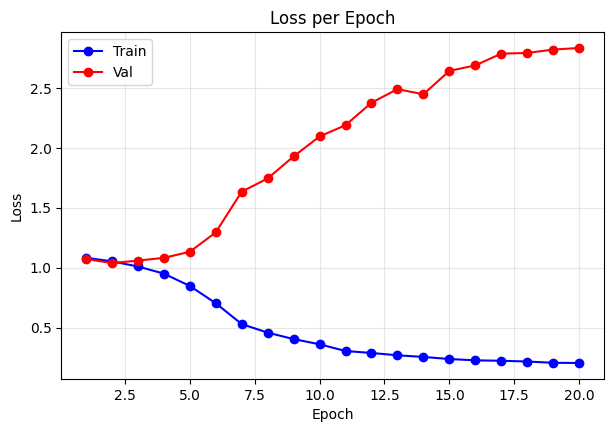

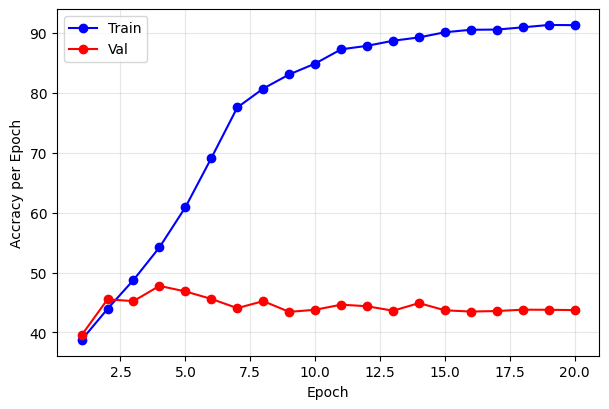

In [28]:
run_name = f"full-finetuning-kaggle"
run_training = True
if run_training:
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()


    print(run_name)
    # Reset randomness
    torch.manual_seed(SEED) # Used to initialized weights and for dropout
    torch.cuda.manual_seed_all(SEED) # Same as above but for GPU
    torch.mps.manual_seed(SEED) # Same as above but for MPS
    generator = torch.Generator().manual_seed(SEED)

    scaler = torch.amp.GradScaler(device.type)
    loss = nn.CrossEntropyLoss()
    learning_rate = 2e-5
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",  # Decrease val loss.
        factor=0.5,
        patience=3,
    )
    # Confirm the runtime actually has the intended device and has a run name
    # before running training.
    if device.type == TARGET_DEVICE and run_name is not None:
        results = train_model(model=model,
                            train_loader=train_loader,
                            val_loader=val_loader,
                            device=device,
                            optimizer=optimizer,
                            loss=loss,
                            num_epochs=20,
                            scaler=scaler,
                            scheduler=scheduler,
                            run_name=run_name
        )

        FULL_WEIGHTS_FILE = os.path.join(PROJECT_ROOT, f"full-model-loss-{results["best_loss"]:.4f}.pt")
        torch.save(
        results["best_model"].state_dict(),
        FULL_WEIGHTS_FILE
        )
        print(f"\nSaved model as: {FULL_WEIGHTS_FILE}\n")
        plot_results(results)
    else:
        print(f"Device is set to {device} (Needs to be set to {TARGET_DEVICE}).")

In [29]:
print(os.cpu_count())
!free -h
!nvidia-smi
import torch
print(torch.cuda.mem_get_info())  # (free, total) in bytes


4
               total        used        free      shared  buff/cache   available
Mem:            31Gi       5.5Gi        17Gi        74Mi       8.2Gi        25Gi
Swap:             0B          0B          0B
Sat Sep 12 22:36:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0      

Expected time after 30 batches: (JUST TRAINING NO VAL RUN)

Time: 13.5

    BATCH_SIZE = 128
    NUM_WORKERS = 2
    MULTIPROCESSING_CONTEXT = None

Time: 12.5

    BATCH_SIZE = 256
    NUM_WORKERS = 2
    MULTIPROCESSING_CONTEXT = None



In [30]:
print(torch.cuda.mem_get_info())


(6917259264, 15636037632)


In [31]:
import gc
gc.collect()
torch.cuda.empty_cache()  # guard with device.type as you already do


In [32]:
print(torch.cuda.mem_get_info())

(12311134208, 15636037632)


### Need to organize

# DELETE after no longer needed
from torch.utils.data import Subset

train_dataset_small = Subset(train_dataset, range(16))
val_dataset_small = Subset(val_dataset, range(16))

train_loader_small = DataLoader(
    train_dataset_small,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    multiprocessing_context=MULTIPROCESSING_CONTEXT,
    collate_fn=partial(collate_cross_encoder, tokenizer=tokenizer),
    generator=generator,
)
val_loader_small = DataLoader(
    val_dataset_small,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    multiprocessing_context=MULTIPROCESSING_CONTEXT,
    collate_fn=partial(collate_cross_encoder, tokenizer=tokenizer),
    generator=generator,
)

### Intial run. Time with calling encoder 3 separate times:
100%|██████████| 180/180 [13:00<00:00,  4.34s/it]
Intitial test accuracy before training: 30.880306193458594

Note:
- adding workers didn't speed up time
- changed from calling encoder 3 times into one time by stacking into one big batch. Didn't improve by much (30 seconds per batch)
- Considered changing max_len on token lengths, but stats on data shows we would lose too much info:

prompt: mean=101.0, median=27,  95th=377, 99th=1390, max=9358
response_a: mean=347.0, median=264,  95th=963, 99th=1961, max=9557
response_b: mean=350.6, median=266,  95th=960, 99th=2014, max=15685

Note:
 - Tried mixed precision and got:
 100%|██████████| 180/180 [05:35<00:00,  1.87s/it]Intitial test accuracy before training: 34.8990953375087
 - Mixed precission and "small" version of model:
 100%|██████████| 180/180 [02:39<00:00,  1.13it/s]Intitial test accuracy before training: 30.897703549060545
 - Mixed precission and "xsmall":
 100%|██████████| 180/180 [02:37<00:00,  1.14it/s]Intitial test accuracy before training: 34.49895615866388

One Epoch 
Time 2m 28s
    BATCH_SIZE = 4
    NUM_WORKERS = 3


Time 8s
    BATCH_SIZE = 128
    NUM_WORKERS = 3

Time 6.4s
BATCH_SIZE = 128
NUM_WORKERS = 6

Time 3.9s
BATCH_SIZE = 256
NUM_WORKERS = 6

Time 2.6s
BATCH_SIZE = 512
NUM_WORKERS = 6

Time 2.1s
BATCH_SIZE = 1024
NUM_WORKERS = 6

Time 2.1s
BATCH_SIZE = 2048
NUM_WORKERS = 6

In [33]:
#runs = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])
#runs